# MVP AFML Validation Notebook

## 概述

本 Notebook 实现 AFML (Advances in Financial Machine Learning) MVP 验证流程：

1. **Dynamic Dollar Bars** - 动态成交额采样
2. **CUSUM Filter** - 事件检测
3. **Trend Scanning** - 趋势方向识别
4. **Triple Barrier Method** - 标签生成
5. **简单回测** - 策略验证

**数据源**: T9999.CCFX 期货 1 分钟数据 (2023-2026)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# AFMLKit imports
from afmlkit.bar.data_model import TradesData
from afmlkit.bar.kit import DynamicDollarBarKit
from afmlkit.sampling.filters import cusum_filter
from afmlkit.feature.core.trend_scan import trend_scan_labels
from afmlkit.label.tbm import triple_barrier

# 设置
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

%matplotlib inline

In [2]:
# ============================================
# 可调参数配置
# ============================================

# Dollar Bars - 搜索范围
DAILY_BARS_RANGE = [4, 8, 20, 30, 40, 50, 60, 80, 100]  # 候选每天 Bar 数
EWMA_SPAN = 20              # 动态阈值 EWMA 平滑周期

# CUSUM Filter
CUSUM_THRESHOLD_MULT = 2.0  # 阈值 = sigma * multiplier
VOL_SPAN = 20               # 波动率 EWMA 平滑周期

# Trend Scanning
L_WINDOWS = [10, 20, 30, 50, 100]  # 候选窗口长度

# Triple Barrier
STOP_LOSS_MULT = 1.5        # 止损 = volatility * STOP_LOSS_MULT
TAKE_PROFIT_MULT = 1.5      # 止盈 = volatility * TAKE_PROFIT_MULT
MAX_HOLD_BARS = 50          # 最大持仓 Bar 数
MIN_CLOSE_TIME_SEC = 0.0    # 最小持仓时间（Bar 数据设为 0）
MIN_RET = 0.0               # 最小收益率阈值（不过滤）

# 数据路径
DATA_PATH = Path('../data/csv/T9999.CCFX-2023-1-1-To-2026-03-11-1m.csv')

## 1. 数据加载

加载 T9999.CCFX 期货 1 分钟 OHLCV 数据，进行基础预处理。

In [3]:
# 加载数据
df = pd.read_csv(DATA_PATH, parse_dates=['datetime'], index_col='datetime')

# 检查数据
print(f"数据形状: {df.shape}")
print(f"时间范围: {df.index.min()} 至 {df.index.max()}")
print(f"\n列名: {df.columns.tolist()}")
print(f"\n前 5 行:")
display(df.head())
print(f"\n数据类型:")
print(df.dtypes)

数据形状: (196080, 7)
时间范围: 2023-01-03 09:31:00 至 2026-03-11 15:00:00

列名: ['open', 'close', 'high', 'low', 'volume', 'open_interest', 'dominant_future']

前 5 行:


,open,close,high,low,volume,open_interest,dominant_future
datetime,,,,,,,
2023-01-03 09:31:00,100.280,100.275,100.310,100.250,1481.0,149987.0,T2303.CCFX
2023-01-03 09:32:00,100.275,100.260,100.280,100.260,467.0,149992.0,T2303.CCFX
2023-01-03 09:33:00,100.265,100.265,100.275,100.245,478.0,150038.0,T2303.CCFX
2023-01-03 09:34:00,100.260,100.265,100.270,100.245,276.0,150026.0,T2303.CCFX
2023-01-03 09:35:00,100.270,100.300,100.300,100.265,752.0,150131.0,T2303.CCFX



数据类型:
open               float64
close              float64
high               float64
low                float64
volume             float64
open_interest      float64
dominant_future     object
dtype: object


In [4]:
# 数据质量检查
print("=== 数据质量检查 ===")
print(f"缺失值:\n{df.isnull().sum()}")
print(f"\n重复时间戳: {df.index.duplicated().sum()}")
print(f"\n基础统计:")
display(df.describe())

# 计算 Dollar Volume
df['dollar_volume'] = df['close'] * df['volume']
print(f"\nDollar Volume 统计:")
print(df['dollar_volume'].describe())

=== 数据质量检查 ===
缺失值:
open               0
close              0
high               0
low                0
volume             0
open_interest      0
dominant_future    0
dtype: int64

重复时间戳: 0

基础统计:


,open,close,high,low,volume,open_interest
count,196080.000000,196080.000000,196080.000000,196080.000000,196080.000000,196080.000000
mean,105.231222,105.231224,105.236788,105.225693,267.187046,181481.524816
std,3.056264,3.056220,3.056673,3.055816,264.748719,33980.342487
min,99.335000,99.335000,99.340000,99.300000,0.000000,60726.000000
25%,102.140000,102.140000,102.150000,102.140000,114.000000,165567.000000
50%,105.725000,105.725000,105.735000,105.720000,204.000000,181846.500000
75%,108.195000,108.195000,108.200000,108.190000,338.000000,195852.000000
max,109.585000,109.575000,109.590000,109.560000,6797.000000,317986.000000



Dollar Volume 统计:
count    196080.000000
mean      28155.887753
std       28052.846087
min           0.000000
25%       11991.287500
50%       21407.185000
75%       35611.950000
max      736726.830000
Name: dollar_volume, dtype: float64


## 2. Dynamic Dollar Bars（基于统计目标优化）

**AFML 核心目标**: 消除时间非均匀性，使收益率 AC1 ≈ 0（低自相关优先于正态性）

**方法**: 搜索最优 TARGET_DAILY_BARS，使 AC1 最接近 0

In [5]:
# ============================================
# Dollar Bars 最优频率搜索
# 目标: 找到使 AC1 ≈ 0 的最优 TARGET_DAILY_BARS
# ============================================

from scipy import stats

def compute_hurst_exponent(series, max_lag=100):
    """计算 Hurst Exponent"""
    lags = range(2, min(max_lag, len(series) // 2))
    tau = [np.std(np.subtract(series[lag:], series[:-lag])) for lag in lags]
    reg = np.polyfit(np.log(lags), np.log(tau), 1)
    return reg[0]

def jarque_bera_test(returns):
    """Jarque-Bera 正态性检验"""
    n = len(returns)
    s = stats.skew(returns)
    k = stats.kurtosis(returns, fisher=True)
    jb = (n / 6) * (s**2 + (k**2) / 4)
    p_value = 1 - stats.chi2.cdf(jb, df=2)
    return jb, p_value

def evaluate_dollar_bars(bars_df, time_returns):
    """评估 Dollar Bars 统计特性，返回综合得分"""
    returns = np.log(bars_df['close']).diff().dropna()
    
    if len(returns) < 100:
        return None, None
    
    # 核心指标
    ac1 = returns.autocorr(lag=1)
    jb, _ = jarque_bera_test(returns.values)
    hurst = compute_hurst_exponent(returns.values)
    
    # 综合评分 (AC1 最重要，权重最高)
    # 目标: AC1 ≈ 0, JB 降低, Hurst ≈ 0.5
    score = (
        -abs(ac1) * 10 +           # AC1 越接近 0 越好
        -np.log1p(jb) / 10 +        # JB 越低越好
        -abs(hurst - 0.5) * 5       # Hurst 越接近 0.5 越好
    )
    
    metrics = {
        'ac1': ac1,
        'jb': jb,
        'hurst': hurst,
        'n_bars': len(bars_df),
        'std': returns.std()
    }
    
    return score, metrics

# 将 1min OHLCV 转换为伪 Tick 数据
timestamps = df.index.astype(np.int64).values
prices = df['close'].values
volumes = df['volume'].values

trades_data = TradesData(ts=timestamps, px=prices, qty=volumes)

# Time Bars 基准
time_returns = np.log(df['close']).diff().dropna()
time_ac1 = time_returns.autocorr(lag=1)
time_jb, _ = jarque_bera_test(time_returns.values)
time_hurst = compute_hurst_exponent(time_returns.values)

print("=" * 70)
print("        Dollar Bars 最优频率搜索（AFML 方法论）")
print("=" * 70)
print(f"\n【基准】Time Bars: AC1={time_ac1:.4f}, JB={time_jb:.0f}, Hurst={time_hurst:.4f}")
print(f"\n搜索范围: {DAILY_BARS_RANGE} bars/day")
print("-" * 70)

# 搜索最优频率
results = []
for target_bars in DAILY_BARS_RANGE:
    builder = DynamicDollarBarKit(
        trades=trades_data,
        target_daily_bars=target_bars,
        ewma_span=EWMA_SPAN
    )
    bars = builder.build_ohlcv()
    score, metrics = evaluate_dollar_bars(bars, time_returns)
    
    if metrics:
        total_days = (bars.index[-1] - bars.index[0]).days
        avg_bars = len(bars) / total_days if total_days > 0 else 0
        
        results.append({
            'target': target_bars,
            'actual_avg': avg_bars,
            'n_bars': metrics['n_bars'],
            'ac1': metrics['ac1'],
            'jb': metrics['jb'],
            'hurst': metrics['hurst'],
            'std': metrics['std'],
            'score': score
        })
        
        status = '✅' if abs(metrics['ac1']) < 0.05 else ''
        print(f"  {target_bars:3d} bars/day → {avg_bars:5.1f}/day | "
              f"AC1={metrics['ac1']:+.4f} {status} | JB={metrics['jb']:8.0f} | H={metrics['hurst']:.3f}")

# 选择最优
if results:
    best = max(results, key=lambda x: x['score'])
    OPTIMAL_DAILY_BARS = best['target']
    
    print("-" * 70)
    print(f"\n✅ 最优频率: {OPTIMAL_DAILY_BARS} bars/day")
    print(f"   AC1 = {best['ac1']:.4f} {'✅ < 0.05' if abs(best['ac1']) < 0.05 else '⚠️'}")
    print(f"   JB 改善: {time_jb:.0f} → {best['jb']:.0f} ({(time_jb - best['jb'])/time_jb*100:.1f}%)")
    print(f"   Hurst = {best['hurst']:.4f} {'✅ ≈ 0.5' if abs(best['hurst'] - 0.5) < 0.1 else '⚠️'}")
else:
    OPTIMAL_DAILY_BARS = 50
    print("\n⚠️ 搜索失败，使用默认值 50 bars/day")

afmlkit.bar.data_model:443 | INFO | Inferred timestamp format: ns


afmlkit.bar.data_model:205 | INFO | TradesData prepared successfully.


        Dollar Bars 最优频率搜索（AFML 方法论）

【基准】Time Bars: AC1=-0.0599, JB=4244844824, Hurst=-0.0004

搜索范围: [4, 8, 20, 30, 40, 50, 60, 80, 100] bars/day
----------------------------------------------------------------------
afmlkit.bar.kit:161 | INFO | Dynamic Dollar bar builder initialized with target_daily_bars: 4, ewma_span: 20


afmlkit.bar.base:106 | INFO | Calculating bar close tick indices and timestamps...


afmlkit.bar.base:146 | INFO | OHLCV bar calculated successfully.


...

   80 bars/day →  52.8/day | AC1=-0.0265 ✅ | JB=177705232 | H=-0.001
afmlkit.bar.kit:161 | INFO | Dynamic Dollar bar builder initialized with target_daily_bars: 100, ewma_span: 20


afmlkit.bar.base:106 | INFO | Calculating bar close tick indices and timestamps...


afmlkit.bar.base:146 | INFO | OHLCV bar calculated successfully.


afmlkit.bar.base:159 | INFO | OHLCV bar converted to DataFrame.


  100 bars/day →  66.1/day | AC1=-0.0350 ✅ | JB=332722890 | H=-0.000
----------------------------------------------------------------------

✅ 最优频率: 8 bars/day
   AC1 = -0.0195 ✅ < 0.05
   JB 改善: 4244844824 → 216950 (100.0%)
   Hurst = -0.0001 ⚠️


In [6]:
# ============================================
# 使用最优频率构建 Dollar Bars
# ============================================

dollar_bar_builder = DynamicDollarBarKit(
    trades=trades_data,
    target_daily_bars=OPTIMAL_DAILY_BARS,
    ewma_span=EWMA_SPAN
)
dollar_bars = dollar_bar_builder.build_ohlcv()

# 计算收益率
dollar_returns = np.log(dollar_bars['close']).diff().dropna()

# 统计验证
dollar_ac1 = dollar_returns.autocorr(lag=1)
dollar_jb, dollar_jb_p = jarque_bera_test(dollar_returns.values)
dollar_hurst = compute_hurst_exponent(dollar_returns.values)

total_days = (dollar_bars.index[-1] - dollar_bars.index[0]).days
avg_bars_per_day = len(dollar_bars) / total_days

print(f"=== 最优 Dollar Bars 构建 ===")
print(f"目标频率: {OPTIMAL_DAILY_BARS} bars/day")
print(f"实际频率: {avg_bars_per_day:.1f} bars/day")
print(f"总 Bar 数: {len(dollar_bars):,}")
print(f"\n统计指标:")
print(f"  AC1: {dollar_ac1:.4f} {'✅' if abs(dollar_ac1) < 0.05 else '⚠️'}")
print(f"  JB:  {dollar_jb:.0f} (Time Bars: {time_jb:.0f})")
print(f"  H:   {dollar_hurst:.4f} {'✅' if abs(dollar_hurst - 0.5) < 0.1 else '⚠️'}")

# 样本展示
print(f"\nDollar Bars 样本:")
display(dollar_bars.head(5))

afmlkit.bar.kit:161 | INFO | Dynamic Dollar bar builder initialized with target_daily_bars: 8, ewma_span: 20


afmlkit.bar.base:106 | INFO | Calculating bar close tick indices and timestamps...


afmlkit.bar.base:146 | INFO | OHLCV bar calculated successfully.


afmlkit.bar.base:159 | INFO | OHLCV bar converted to DataFrame.


=== 最优 Dollar Bars 构建 ===
目标频率: 8 bars/day
实际频率: 5.3 bars/day
总 Bar 数: 6,146

统计指标:
  AC1: -0.0195 ✅
  JB:  216950 (Time Bars: 4244844824)
  H:   -0.0001 ⚠️

Dollar Bars 样本:


,open,high,low,close,volume,trades,median_trade_size,vwap
timestamp,,,,,,,,
2023-01-03 09:44:00,100.260,100.360,100.260,100.340,5658.0,13,478.0,100.314113
2023-01-03 10:22:00,100.340,100.355,100.295,100.295,6613.0,38,142.0,100.326618
2023-01-03 10:54:00,100.300,100.300,100.215,100.260,6749.0,32,167.0,100.247918
2023-01-03 13:39:00,100.240,100.260,100.225,100.225,6541.0,75,60.0,100.244300
2023-01-03 14:13:00,100.225,100.225,100.160,100.170,6660.0,34,183.0,100.184828


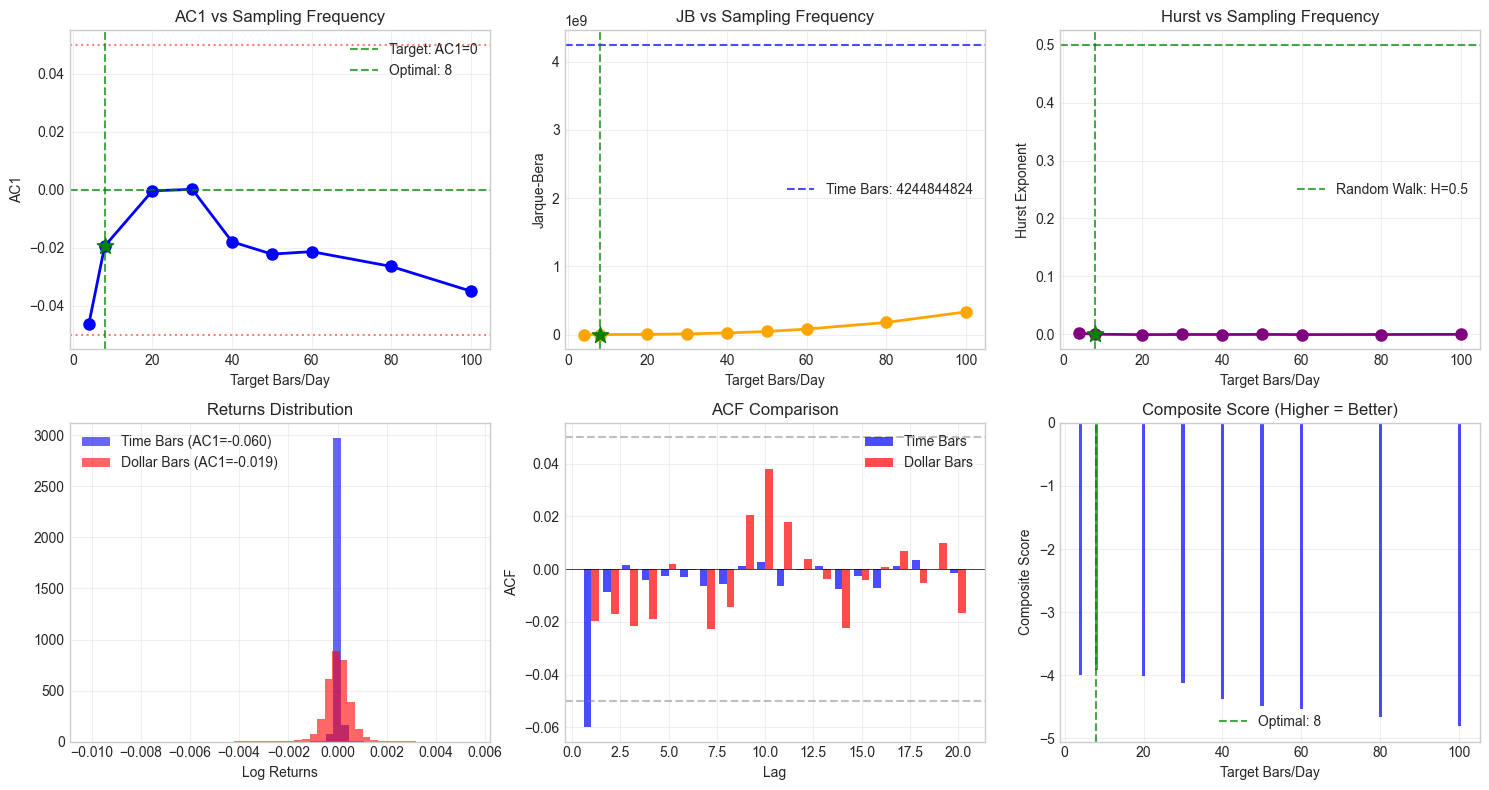

In [7]:
# ============================================
# Dollar Bars 频率搜索结果可视化
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 1. AC1 vs 频率
ax1 = axes[0, 0]
targets = [r['target'] for r in results]
ac1s = [r['ac1'] for r in results]
ax1.plot(targets, ac1s, 'o-', color='blue', markersize=8, linewidth=2)
ax1.axhline(y=0, color='green', linestyle='--', alpha=0.7, label='Target: AC1=0')
ax1.axhline(y=0.05, color='red', linestyle=':', alpha=0.5)
ax1.axhline(y=-0.05, color='red', linestyle=':', alpha=0.5)
ax1.axvline(x=OPTIMAL_DAILY_BARS, color='green', linestyle='--', alpha=0.7, label=f'Optimal: {OPTIMAL_DAILY_BARS}')
ax1.scatter([OPTIMAL_DAILY_BARS], [dollar_ac1], color='green', s=150, zorder=5, marker='*')
ax1.set_xlabel('Target Bars/Day')
ax1.set_ylabel('AC1')
ax1.set_title('AC1 vs Sampling Frequency')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. JB vs 频率
ax2 = axes[0, 1]
jbs = [r['jb'] for r in results]
ax2.plot(targets, jbs, 'o-', color='orange', markersize=8, linewidth=2)
ax2.axhline(y=time_jb, color='blue', linestyle='--', alpha=0.7, label=f'Time Bars: {time_jb:.0f}')
ax2.axvline(x=OPTIMAL_DAILY_BARS, color='green', linestyle='--', alpha=0.7)
ax2.scatter([OPTIMAL_DAILY_BARS], [dollar_jb], color='green', s=150, zorder=5, marker='*')
ax2.set_xlabel('Target Bars/Day')
ax2.set_ylabel('Jarque-Bera')
ax2.set_title('JB vs Sampling Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Hurst vs 频率
ax3 = axes[0, 2]
hursts = [r['hurst'] for r in results]
ax3.plot(targets, hursts, 'o-', color='purple', markersize=8, linewidth=2)
ax3.axhline(y=0.5, color='green', linestyle='--', alpha=0.7, label='Random Walk: H=0.5')
ax3.axvline(x=OPTIMAL_DAILY_BARS, color='green', linestyle='--', alpha=0.7)
ax3.scatter([OPTIMAL_DAILY_BARS], [dollar_hurst], color='green', s=150, zorder=5, marker='*')
ax3.set_xlabel('Target Bars/Day')
ax3.set_ylabel('Hurst Exponent')
ax3.set_title('Hurst vs Sampling Frequency')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. 收益率分布对比
ax4 = axes[1, 0]
ax4.hist(time_returns, bins=50, alpha=0.6, label=f'Time Bars (AC1={time_ac1:.3f})', color='blue', density=True)
ax4.hist(dollar_returns, bins=50, alpha=0.6, label=f'Dollar Bars (AC1={dollar_ac1:.3f})', color='red', density=True)
ax4.set_title('Returns Distribution')
ax4.set_xlabel('Log Returns')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. ACF 对比
ax5 = axes[1, 1]
time_acf = [time_returns.autocorr(lag=i) for i in range(1, 21)]
dollar_acf = [dollar_returns.autocorr(lag=i) for i in range(1, 21)]
ax5.bar(np.arange(1, 21) - 0.2, time_acf, width=0.4, label='Time Bars', color='blue', alpha=0.7)
ax5.bar(np.arange(1, 21) + 0.2, dollar_acf, width=0.4, label='Dollar Bars', color='red', alpha=0.7)
ax5.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax5.axhline(y=0.05, color='gray', linestyle='--', alpha=0.5)
ax5.axhline(y=-0.05, color='gray', linestyle='--', alpha=0.5)
ax5.set_title('ACF Comparison')
ax5.set_xlabel('Lag')
ax5.set_ylabel('ACF')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. 综合得分
ax6 = axes[1, 2]
scores = [r['score'] for r in results]
colors = ['green' if t == OPTIMAL_DAILY_BARS else 'blue' for t in targets]
ax6.bar(targets, scores, color=colors, alpha=0.7)
ax6.axvline(x=OPTIMAL_DAILY_BARS, color='green', linestyle='--', alpha=0.7, label=f'Optimal: {OPTIMAL_DAILY_BARS}')
ax6.set_xlabel('Target Bars/Day')
ax6.set_ylabel('Composite Score')
ax6.set_title('Composite Score (Higher = Better)')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dollar_bars_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ============================================
# 3. CUSUM Filter（基于目标优化阈值）
# 
# CUSUM 目标（AFML）:
# - 检测结构性突变，只在市场真正发生"异动"时采样
# - 过滤噪音，避免过度采样或采样稀疏
#
# 验证指标：
# - 事件触发频率：合理（目标 10-30% of bars）
# - 过滤后样本波动率：更加平稳
# ============================================

# 使用已计算的 dollar_returns
# 计算 EWMA 波动率
volatility = dollar_returns.ewm(span=VOL_SPAN).std()

print("=" * 70)
print("        CUSUM Filter 阈值优化")
print("=" * 70)
print(f"\n【AFML 目标】")
print(f"  - 检测结构性突变（累计偏离超过阈值）")
print(f"  - 合理的事件频率：10-30% of bars")
print(f"  - 过滤噪音，捕捉真实信号")

# 搜索最优阈值乘数
THRESHOLD_RANGE = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]
cusum_results = []

print(f"\n搜索范围: {THRESHOLD_RANGE} × volatility")
print("-" * 70)

for mult in THRESHOLD_RANGE:
    thresh = (volatility.values * mult).astype(np.float64)
    indices = cusum_filter(dollar_returns.values.astype(np.float64), thresh)
    
    event_pct = len(indices) / len(dollar_returns) * 100
    
    # 计算过滤后收益率波动率
    if len(indices) > 10:
        filtered_returns = dollar_returns.iloc[indices]
        filtered_vol = filtered_returns.std()
        raw_vol = dollar_returns.std()
        vol_ratio = filtered_vol / raw_vol
    else:
        vol_ratio = np.nan
    
    # 目标：事件频率 10-30%，波动率比率合理
    # 评分：频率接近 20% 得分最高
    freq_score = -abs(event_pct - 20)  # 越接近 20% 越好
    vol_score = -abs(vol_ratio - 1.0) * 5 if not np.isnan(vol_ratio) else -100  # 波动率比率接近 1
    score = freq_score + vol_score
    
    cusum_results.append({
        'mult': mult,
        'n_events': len(indices),
        'event_pct': event_pct,
        'vol_ratio': vol_ratio,
        'score': score
    })
    
    status = '✅' if 10 <= event_pct <= 30 else ''
    print(f"  {mult:.1f}x → {len(indices):4d} events ({event_pct:5.1f}%) | "
          f"Vol Ratio={vol_ratio:.2f} {status}")

# 选择最优
best_cusum = max(cusum_results, key=lambda x: x['score'])
OPTIMAL_CUSUM_MULT = best_cusum['mult']

print("-" * 70)
print(f"\n✅ 最优阈值乘数: {OPTIMAL_CUSUM_MULT}")
print(f"   事件数: {best_cusum['n_events']}")
print(f"   事件频率: {best_cusum['event_pct']:.1f}% {'✅' if 10 <= best_cusum['event_pct'] <= 30 else '⚠️'}")

# 使用最优阈值
threshold = (volatility.values * OPTIMAL_CUSUM_MULT).astype(np.float64)
event_indices = cusum_filter(dollar_returns.values.astype(np.float64), threshold)
event_times = dollar_returns.index[event_indices]

print(f"\n=== 最终 CUSUM Filter 结果 ===")
print(f"检测到事件数: {len(event_indices)}")
print(f"事件占比: {len(event_indices) / len(dollar_returns) * 100:.1f}%")
print(f"\n事件时间样例:")
for i, t in enumerate(event_times[:5]):
    print(f"  {i+1}. {t}")

        CUSUM Filter 阈值优化

【AFML 目标】
  - 检测结构性突变（累计偏离超过阈值）
  - 合理的事件频率：10-30% of bars
  - 过滤噪音，捕捉真实信号

搜索范围: [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0] × volatility
----------------------------------------------------------------------
  0.5x → 3948 events ( 64.2%) | Vol Ratio=1.23 
  1.0x → 2446 events ( 39.8%) | Vol Ratio=1.46 
  1.5x → 1664 events ( 27.1%) | Vol Ratio=1.62 ✅
  2.0x → 1172 events ( 19.1%) | Vol Ratio=1.72 ✅
  2.5x →  863 events ( 14.0%) | Vol Ratio=1.83 ✅
  3.0x →  663 events ( 10.8%) | Vol Ratio=1.85 ✅
  4.0x →  445 events (  7.2%) | Vol Ratio=1.47 
  5.0x →  312 events (  5.1%) | Vol Ratio=1.21 
----------------------------------------------------------------------

✅ 最优阈值乘数: 2.0
   事件数: 1172
   事件频率: 19.1% ✅

=== 最终 CUSUM Filter 结果 ===
检测到事件数: 1172
事件占比: 19.1%

事件时间样例:
  1. 2023-01-03 10:54:00
  2. 2023-01-03 13:39:00
  3. 2023-01-03 14:13:00
  4. 2023-01-03 15:02:00
  5. 2023-01-04 13:30:00


## 4. Trend Scanning

对每个 CUSUM 事件点执行 Trend Scanning，确定趋势方向（side）和置信度（t-value）。

In [9]:
# 准备输入数据
price_series = dollar_bars['close'].copy()

# 执行 Trend Scanning
trend_df = trend_scan_labels(
    price_series=price_series,
    t_events=event_times,
    L_windows=L_WINDOWS
)

print(f"=== Trend Scanning 结果 ===")
print(f"成功处理事件数: {len(trend_df)}")
print(f"\n结果样例:")
display(trend_df.tail(10))


afmlkit.feature.core.trend_scan:275 | INFO | Running Trend Scan: 1172 events × 5 windows (max L=100)...


afmlkit.feature.core.trend_scan:301 | INFO | Trend Scan complete: 1172 events → 744 up / 424 down / 4 flat


=== Trend Scanning 结果 ===
成功处理事件数: 1172

结果样例:


,t1,t_value,side
timestamp,,,
2026-02-25 13:15:00,100,18.228388,1
2026-02-26 09:33:00,100,14.388465,1
2026-02-26 09:45:00,100,12.791505,1
2026-02-27 14:43:00,30,-7.549706,-1
2026-03-02 10:09:00,50,-5.736304,-1
2026-03-04 11:29:00,20,6.720125,1
2026-03-05 11:22:00,30,11.168863,1
2026-03-09 09:33:00,50,4.316808,1
2026-03-10 09:31:00,30,-7.664670,-1


In [10]:
# 统计分析
n_up = (trend_df['side'] == 1).sum()
n_down = (trend_df['side'] == -1).sum()
n_flat = (trend_df['side'] == 0).sum()

print(f"=== Trend Scanning 统计 ===")
print(f"看涨信号 (side=+1): {n_up} ({n_up/len(trend_df)*100:.1f}%)")
print(f"看跌信号 (side=-1): {n_down} ({n_down/len(trend_df)*100:.1f}%)")
print(f"无趋势 (side=0): {n_flat} ({n_flat/len(trend_df)*100:.1f}%)")
print(f"\nt-value 分布:")
print(f"  均值: {trend_df['t_value'].mean():.2f}")
print(f"  标准差: {trend_df['t_value'].std():.2f}")
print(f"  最大绝对值: {trend_df['t_value'].abs().max():.2f}")
print(f"\n最优窗口分布:")
print(trend_df['t1'].value_counts().sort_index())

=== Trend Scanning 统计 ===
看涨信号 (side=+1): 744 (63.5%)
看跌信号 (side=-1): 424 (36.2%)
无趋势 (side=0): 4 (0.3%)

t-value 分布:
  均值: 5.37
  标准差: 16.01
  最大绝对值: 49.47

最优窗口分布:
t1
0        4
10      55
20      87
30     177
50     299
100    550
Name: count, dtype: int64


## 5. Triple Barrier Method

使用动态波动率倍数设置止盈止损，生成交易标签。

In [11]:
# 计算平均 Bar 持续时间（秒）
bar_timestamps = dollar_bars.index.astype(np.int64).values
avg_bar_duration_sec = np.mean(np.diff(bar_timestamps)) / 1e9

# 计算每个事件点的波动率 target
# 需要将事件时间映射到 volatility Series 的位置
volatility_targets = volatility.loc[trend_df.index].values.astype(np.float64)

# 准备事件索引（在 close 数组中的位置）
event_positions = dollar_bars.index.get_indexer(trend_df.index)

print(f"=== TBM 参数 ===")
print(f"平均 Bar 持续时间: {avg_bar_duration_sec:.1f} 秒")
print(f"止损倍数: {STOP_LOSS_MULT}")
print(f"止盈倍数: {TAKE_PROFIT_MULT}")
print(f"最大持仓时间: {MAX_HOLD_BARS} 根 Bar ({MAX_HOLD_BARS * avg_bar_duration_sec:.0f} 秒)")
print(f"\n波动率 Target 统计:")
print(f"  均值: {np.nanmean(volatility_targets):.6f}")
print(f"  最小: {np.nanmin(volatility_targets):.6f}")
print(f"  最大: {np.nanmax(volatility_targets):.6f}")

=== TBM 参数 ===
平均 Bar 持续时间: 16352.1 秒
止损倍数: 1.5
止盈倍数: 1.5
最大持仓时间: 50 根 Bar (817604 秒)

波动率 Target 统计:
  均值: 0.000514
  最小: 0.000056
  最大: 0.003027


In [12]:
# 执行 Triple Barrier Method
labels, touch_idxs, rets, max_rb_ratios = triple_barrier(
    timestamps=bar_timestamps,
    close=dollar_bars['close'].values.astype(np.float64),
    event_idxs=event_positions.astype(np.int64),
    targets=volatility_targets,
    horizontal_barriers=(STOP_LOSS_MULT, TAKE_PROFIT_MULT),
    vertical_barrier=MAX_HOLD_BARS * avg_bar_duration_sec,
    min_close_time_sec=MIN_CLOSE_TIME_SEC,
    side=None,  # Side prediction 模式
    min_ret=MIN_RET
)

# 创建结果 DataFrame
tbm_df = pd.DataFrame({
    'label': labels,
    'touch_idx': touch_idxs,
    'return': rets,
    'max_rb_ratio': max_rb_ratios
}, index=trend_df.index)

print(f"=== Triple Barrier Method 结果 ===")
print(f"处理事件数: {len(tbm_df)}")
print(f"\n结果样例:")
display(tbm_df.head(10))

1674226080000000000 1.6750436837428805e+18
1695913440000000000 1.6967310437428805e+18
1770995520000000000 1.7718131237428805e+18
=== Triple Barrier Method 结果 ===
处理事件数: 1172

结果样例:


,label,touch_idx,return,max_rb_ratio
timestamp,,,,
2023-01-03 10:54:00,-1,3,-0.000349,1.0
2023-01-03 13:39:00,-1,4,-0.000549,1.0
2023-01-03 14:13:00,1,5,0.000699,1.0
2023-01-03 15:02:00,-1,33,-0.001944,1.0
2023-01-04 13:30:00,-1,23,-0.001693,1.0
2023-01-06 09:39:00,-1,32,-0.000897,1.0
2023-01-06 13:41:00,1,38,0.000798,1.0
2023-01-09 10:19:00,1,35,0.001097,1.0
2023-01-09 13:18:00,-1,40,-0.000898,1.0


In [13]:
# 标签分布统计
n_profit = (tbm_df['label'] == 1).sum()
n_loss = (tbm_df['label'] == -1).sum()
n_timeout = (tbm_df['label'] == 0).sum()

print(f"=== TBM 标签分布 ===")
print(f"止盈 (+1): {n_profit} ({n_profit/len(tbm_df)*100:.1f}%)")
print(f"止损 (-1): {n_loss} ({n_loss/len(tbm_df)*100:.1f}%)")
print(f"时间到期 (0): {n_timeout} ({n_timeout/len(tbm_df)*100:.1f}%)")

# 持仓时间统计
hold_times = []
for idx, row in tbm_df.iterrows():
    event_idx = event_positions[tbm_df.index.get_loc(idx)]
    touch_idx = int(row['touch_idx'])
    if touch_idx >= 0 and touch_idx < len(dollar_bars):
        start_time = dollar_bars.index[event_idx]
        end_time = dollar_bars.index[touch_idx]
        hold_times.append((end_time - start_time).total_seconds() / 3600)  # 小时

print(f"\n持仓时间统计 (小时):")
print(f"  平均: {np.mean(hold_times):.2f}")
print(f"  中位数: {np.median(hold_times):.2f}")
print(f"  最长: {np.max(hold_times):.2f}")

=== TBM 标签分布 ===
止盈 (+1): 626 (53.4%)
止损 (-1): 543 (46.3%)
时间到期 (0): 3 (0.3%)

持仓时间统计 (小时):
  平均: 24.99
  中位数: 19.21
  最长: 221.52


## 6. 简单回测

基于 Trend Scanning 信号和 TBM 标签进行简单策略回测。

In [14]:
# 合并 Trend Scanning 和 TBM 结果
# trend_df 列: ['t1', 't_value', 'side']
# tbm_df 列: ['label', 'touch_idx', 'return', 'max_rb_ratio']
results_df = pd.concat([trend_df, tbm_df], axis=1)
# 最终列: ['t1', 't_value', 'side', 'label', 'touch_idx', 'return', 'max_rb_ratio']

# 计算策略收益
# 每笔交易收益 = side * return
# side: +1 做多, -1 做空
# return: TBM 计算的收益率（已考虑方向）
results_df['trade_return'] = results_df['side'] * results_df['return']

print(f"=== 交易结果 ===")
print(f"总交易数: {len(results_df)}")
print(f"\n交易收益统计:")
print(f"  均值: {results_df['trade_return'].mean():.6f}")
print(f"  标准差: {results_df['trade_return'].std():.6f}")
print(f"  最大: {results_df['trade_return'].max():.6f}")
print(f"  最小: {results_df['trade_return'].min():.6f}")

# 胜率计算
winning_trades = (results_df['trade_return'] > 0).sum()
losing_trades = (results_df['trade_return'] < 0).sum()
win_rate = winning_trades / len(results_df) * 100

print(f"\n胜率: {win_rate:.1f}% ({winning_trades}/{len(results_df)})")

=== 交易结果 ===
总交易数: 1172

交易收益统计:
  均值: 0.000021
  标准差: 0.001319
  最大: 0.008698
  最小: -0.010411

胜率: 51.8% (607/1172)


In [15]:
# 计算累计收益
cumulative_returns = (1 + results_df['trade_return']).cumprod()

# 计算最大回撤
running_max = cumulative_returns.expanding().max()
drawdown = (cumulative_returns - running_max) / running_max
max_drawdown = drawdown.min()

# 计算 Sharpe Ratio
# 年化因子：基于实际交易频率
total_days = (results_df.index[-1] - results_df.index[0]).days
trades_per_year = len(results_df) / total_days * 252
ann_factor = np.sqrt(trades_per_year)

sharpe_ratio = results_df['trade_return'].mean() / results_df['trade_return'].std() * ann_factor

print(f"=== 策略绩效 ===")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"最大回撤: {max_drawdown:.2%}")
print(f"累计收益: {(cumulative_returns.iloc[-1] - 1):.2%}")
print(f"年化收益: {(cumulative_returns.iloc[-1] ** (252/total_days) - 1):.2%}")

=== 策略绩效 ===
Sharpe Ratio: 0.25
最大回撤: -3.78%
累计收益: 2.35%
年化收益: 0.51%


## 7. 可视化分析

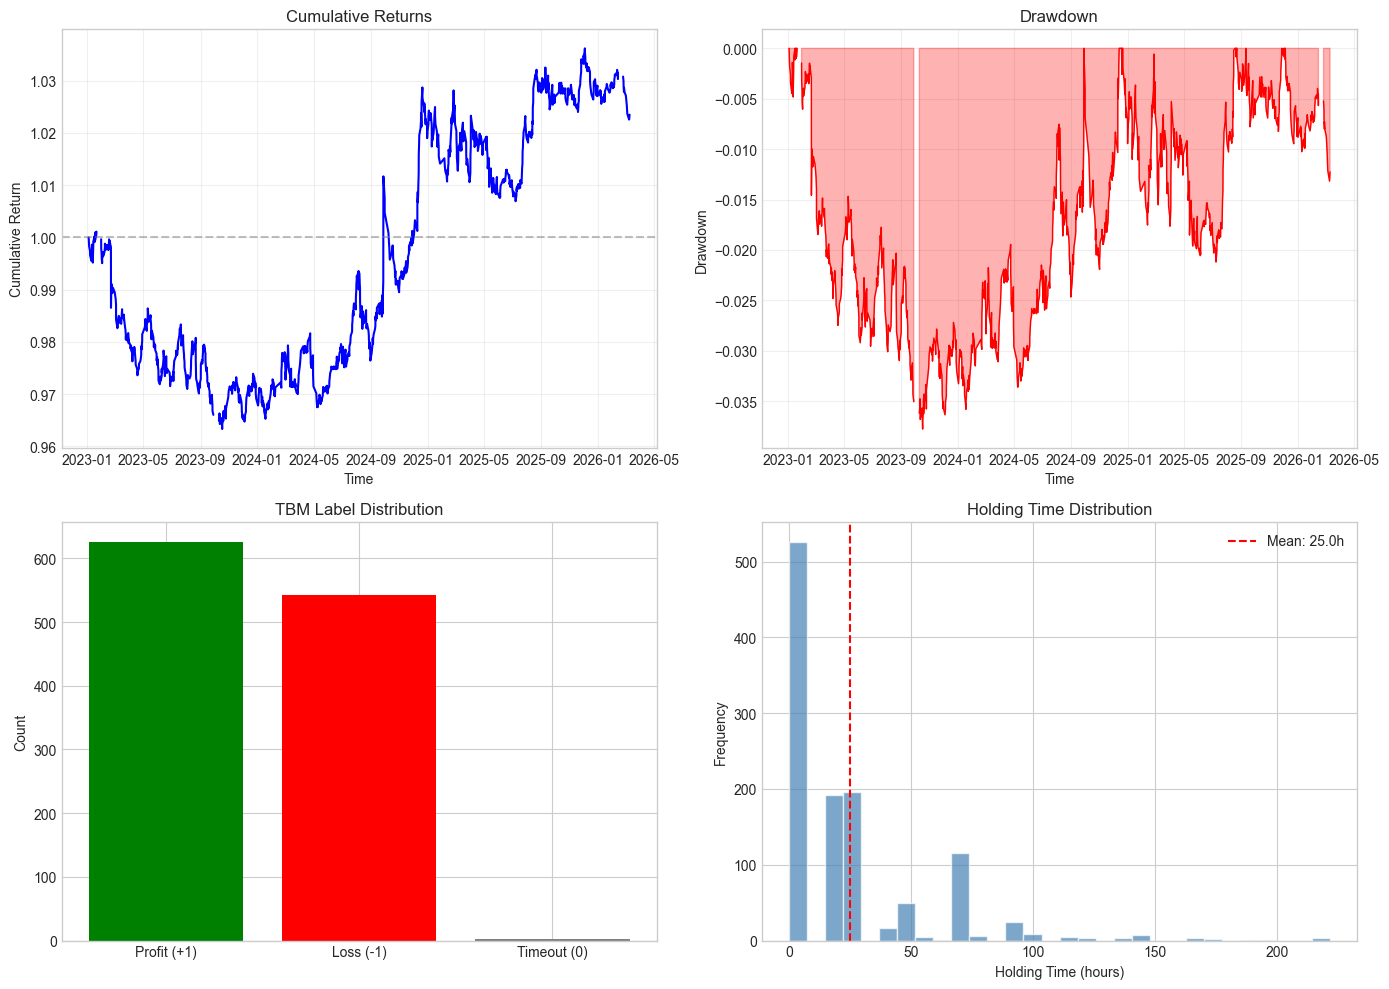

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 累计收益曲线
ax1 = axes[0, 0]
ax1.plot(cumulative_returns.index, cumulative_returns.values, 'b-', linewidth=1.5)
ax1.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
ax1.set_title('Cumulative Returns', fontsize=12)
ax1.set_xlabel('Time')
ax1.set_ylabel('Cumulative Return')
ax1.grid(True, alpha=0.3)

# 2. 回撤曲线
ax2 = axes[0, 1]
ax2.fill_between(drawdown.index, drawdown.values, 0, color='red', alpha=0.3)
ax2.plot(drawdown.index, drawdown.values, 'r-', linewidth=1)
ax2.set_title('Drawdown', fontsize=12)
ax2.set_xlabel('Time')
ax2.set_ylabel('Drawdown')
ax2.grid(True, alpha=0.3)

# 3. 标签分布
ax3 = axes[1, 0]
label_counts = tbm_df['label'].value_counts()
colors = ['green' if x == 1 else 'red' if x == -1 else 'gray' for x in label_counts.index]
ax3.bar(['Profit (+1)', 'Loss (-1)', 'Timeout (0)'] if len(label_counts) == 3 else label_counts.index,
        label_counts.values, color=colors)
ax3.set_title('TBM Label Distribution', fontsize=12)
ax3.set_ylabel('Count')

# 4. 持仓时间分布
ax4 = axes[1, 1]
ax4.hist(hold_times, bins=30, color='steelblue', edgecolor='white', alpha=0.7)
ax4.axvline(x=np.mean(hold_times), color='red', linestyle='--', label=f'Mean: {np.mean(hold_times):.1f}h')
ax4.set_title('Holding Time Distribution', fontsize=12)
ax4.set_xlabel('Holding Time (hours)')
ax4.set_ylabel('Frequency')
ax4.legend()

plt.tight_layout()
plt.savefig('mvp_validation_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# 输出最终汇总表格
print("=" * 60)
print("            MVP VALIDATION RESULTS")
print("=" * 60)
print(f"{'Data Period:':<25} {dollar_bars.index[0].date()} to {dollar_bars.index[-1].date()}")
print(f"{'Dollar Bars:':<25} {len(dollar_bars):,} (avg {avg_bars_per_day:.1f}/day)")
print(f"{'CUSUM Events:':<25} {len(event_indices):,}")
print(f"{'Trend Scan Signals:':<25} {n_up} up / {n_down} down")
print(f"{'TBM Labels:':<25} +1:{n_profit}, -1:{n_loss}, 0:{n_timeout}")
print("-" * 60)
print(f"{'Strategy Sharpe:':<25} {sharpe_ratio:.2f}")
print(f"{'Max Drawdown:':<25} {max_drawdown:.2%}")
print(f"{'Win Rate:':<25} {win_rate:.1f}%")
print(f"{'Total Trades:':<25} {len(results_df):,}")
print("=" * 60)

# 成功判定
success = True
issues = []

if sharpe_ratio < 1.0:
    success = False
    issues.append("Sharpe Ratio < 1.0")
if abs(max_drawdown) > 0.30:
    success = False
    issues.append("Max Drawdown > 30%")
if win_rate < 45:
    success = False
    issues.append("Win Rate < 45%")

if success:
    print("\n✅ MVP 验证通过！趋势策略在该标的上显示有效性。")
    print("   建议下一步：添加 FracDiff、Meta-Labeling、Purged CV 等高级组件。")
else:
    print(f"\n❌ MVP 验证未通过。问题：{', '.join(issues)}")
    print("   建议：检查参数配置，或尝试其他标的/时间段。")

            MVP VALIDATION RESULTS
Data Period:              2023-01-03 to 2026-03-11
Dollar Bars:              6,146 (avg 5.3/day)
CUSUM Events:             1,172
Trend Scan Signals:       744 up / 424 down
TBM Labels:               +1:626, -1:543, 0:3
------------------------------------------------------------
Strategy Sharpe:          0.25
Max Drawdown:             -3.78%
Win Rate:                 51.8%
Total Trades:             1,172

❌ MVP 验证未通过。问题：Sharpe Ratio < 1.0
   建议：检查参数配置，或尝试其他标的/时间段。
